# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2874s 17us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

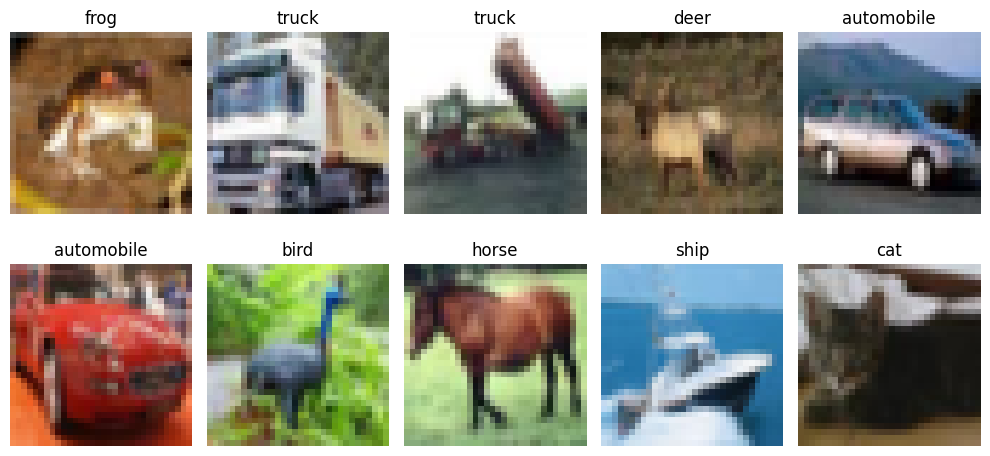

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.2773 - loss: 1.9836 - val_accuracy: 0.3538 - val_loss: 1.8077
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3258 - loss: 1.8543 - val_accuracy: 0.3736 - val_loss: 1.7733
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3454 - loss: 1.8025 - val_accuracy: 0.3944 - val_loss: 1.7259
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3630 - loss: 1.7637 - val_accuracy: 0.3858 - val_loss: 1.6959
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3741 - loss: 1.7276 - val_accuracy: 0.4062 - val_loss: 1.6725
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3788 - loss: 1.7110 - val_accuracy: 0.4084 - val_loss: 1.6739
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3880 - loss: 1.6950 - val_accuracy: 0.4280 - val_loss: 1.6376
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.3960 - loss: 1.6708 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4370 - loss: 1.6048
ANN Test Accuracy: 0.43700000643730164


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 115ms/step - accuracy: 0.4679 - loss: 1.4992 - val_accuracy: 0.4670 - val_loss: 1.5484
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.6045 - loss: 1.1365 - val_accuracy: 0.5994 - val_loss: 1.1315
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 110ms/step - accuracy: 0.6670 - loss: 0.9510 - val_accuracy: 0.6084 - val_loss: 1.1379
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.7084 - loss: 0.8369 - val_accuracy: 0.6936 - val_loss: 0.8962
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 115ms/step - accuracy: 0.7426 - loss: 0.7371 - val_accuracy: 0.7000 - val_loss: 0.8921
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.7680 - loss: 0.6551 - val_accuracy: 0.6878 - val_loss: 0.9380
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.7906 - loss: 0.5908 - val_accuracy: 0.6804 - val_loss: 1.0261
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.8118 - loss: 0

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7281 - loss: 0.9259
CNN Test Accuracy: 0.7281000018119812


## 📈 Compare Learning Curves

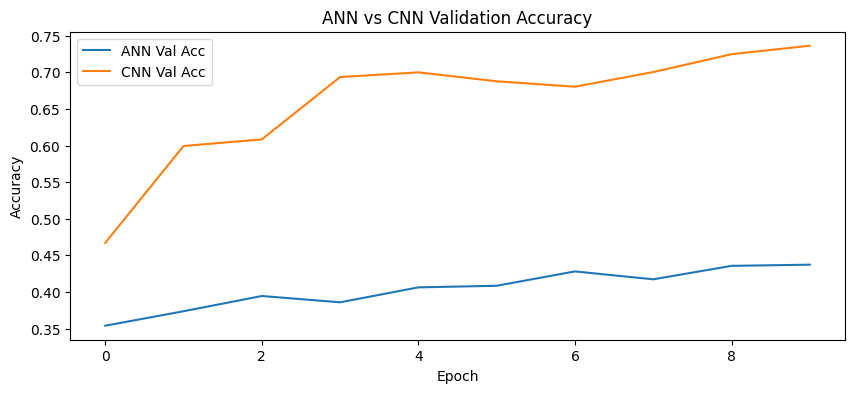

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 46ms/step - accuracy: 0.3714 - loss: 1.7191 - val_accuracy: 0.5006 - val_loss: 1.3565
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.4727 - loss: 1.4610 - val_accuracy: 0.5526 - val_loss: 1.2487
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 45ms/step - accuracy: 0.5126 - loss: 1.3708 - val_accuracy: 0.5776 - val_loss: 1.1801
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.5323 - loss: 1.3146 - val_accuracy: 0.6004 - val_loss: 1.1499
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.5486 - loss: 1.2758 - val_accuracy: 0.6078 - val_loss: 1.1014
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.5594 - loss: 1.2452 - val_accuracy: 0.6336 - val_loss: 1.0464
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.5727 - loss: 1.2184 - val_accuracy: 0.6232 - val_loss: 1.0760
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.5761 -

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4370
1,CNN,0.7281


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

### Task 1: Increase ANN layers, epochs, and add EarlyStopping

In [14]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models

# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Create a new ANN model with more layers
ann_model_v2 = models.Sequential([
    layers.Input(shape=(3072,)), # Corrected: Use layers.Input
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ANN Model V2 with more layers, 20 epochs, and EarlyStopping...")
ann_history_v2 = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

ann_test_loss_v2, ann_test_acc_v2 = ann_model_v2.evaluate(x_test_flat, y_test)
print("ANN Model V2 Test Accuracy:", ann_test_acc_v2)

Training ANN Model V2 with more layers, 20 epochs, and EarlyStopping...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.3170 - loss: 1.9472 - val_accuracy: 0.2950 - val_loss: 1.9783
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3793 - loss: 1.7279 - val_accuracy: 0.3890 - val_loss: 1.6828
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3992 - loss: 1.6747 - val_accuracy: 0.3800 - val_loss: 1.7013
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.4142 - loss: 1.6353 - val_accuracy: 0.4336 - val_loss: 1.6160
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4170 - loss: 1.6313 - val_accuracy: 0.4262 - val_loss: 1.6136
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.4182 - loss: 1.6213 - val_accuracy: 0.4240 - val_loss: 1.6111
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4214 - loss: 1.6162 - val_accuracy: 0.4302 - val_loss: 1.5798
Epoch 8/20
704/704

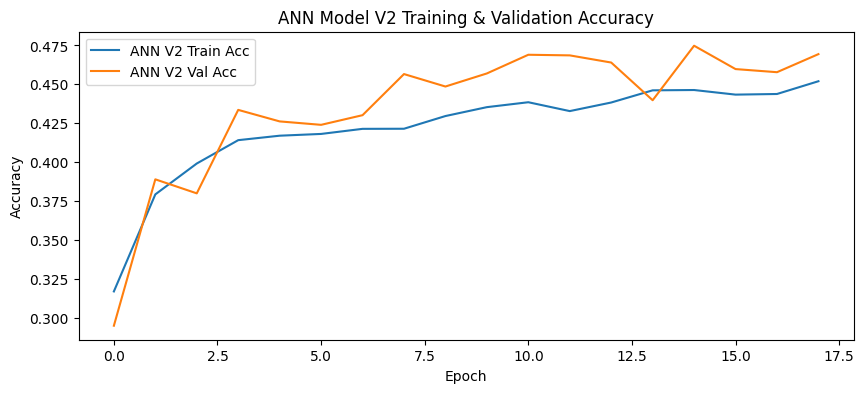

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(ann_history_v2.history['accuracy'], label='ANN V2 Train Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN V2 Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Model V2 Training & Validation Accuracy")
plt.legend()
plt.show()

### Task 2: Change CNN filters, increase epochs, and add EarlyStopping

In [16]:
# Create a new CNN model with increased filters
cnn_model_v2 = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN Model V2 with increased filters, 20 epochs, and EarlyStopping...")
cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

cnn_test_loss_v2, cnn_test_acc_v2 = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN Model V2 Test Accuracy:", cnn_test_acc_v2)

Training CNN Model V2 with increased filters, 20 epochs, and EarlyStopping...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 215s 301ms/step - accuracy: 0.4899 - loss: 1.6160 - val_accuracy: 0.5280 - val_loss: 1.2715
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 299ms/step - accuracy: 0.6490 - loss: 1.0051 - val_accuracy: 0.3312 - val_loss: 2.4241
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 209s 298ms/step - accuracy: 0.7083 - loss: 0.8285 - val_accuracy: 0.5636 - val_loss: 1.3169
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 265s 301ms/step - accuracy: 0.7516 - loss: 0.7075 - val_accuracy: 0.6626 - val_loss: 0.9799
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 209s 296ms/step - accuracy: 0.7878 - loss: 0.5990 - val_accuracy: 0.7142 - val_loss: 0.8829
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 209s 296ms/step - accuracy: 0.8245 - loss: 0.4997 - val_accuracy: 0.6792 - val_loss: 1.0577
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 210s 298ms/step - accuracy: 0.8465 - loss: 0.4338 - val_accuracy: 0.6740 - val_loss: 1.186

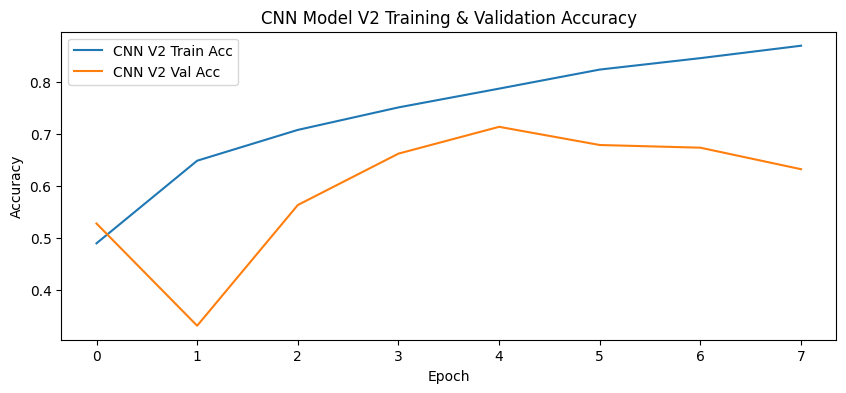

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(cnn_history_v2.history['accuracy'], label='CNN V2 Train Acc')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN V2 Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Model V2 Training & Validation Accuracy")
plt.legend()
plt.show()

### Task 3: Evaluate Data Augmentation Training

In [19]:
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6367 - loss: 1.0456
Augmented CNN Test Accuracy: 0.6366999745368958


## Final Comparison Table

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "ANN (Original)",
        "CNN (Original)",
        "ANN V2 (More Layers, 20 Epochs, EarlyStopping)",
        "CNN V2 (More Filters, 20 Epochs, EarlyStopping)",
        "CNN (Augmented Data, 10 Epochs)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_test_acc_v2,
        cnn_test_acc_v2,
        aug_cnn_test_acc
    ],
    "Epochs Trained": [
        10,
        10,
        len(ann_history_v2.history['accuracy']),
        len(cnn_history_v2.history['accuracy']),
        len(aug_history.history['accuracy'])
    ],
    "Strategy": [
        "Basic ANN",
        "Basic CNN",
        "More Layers + EarlyStopping",
        "More Filters + EarlyStopping",
        "Data Augmentation"
    ]
})

comparison

,Model,Test Accuracy,Epochs Trained,Strategy
0,ANN (Original),0.4370,10,Basic ANN
1,CNN (Original),0.7281,10,Basic CNN
2,"ANN V2 (More Layers, 20 Epochs, EarlyStopping)",0.4789,18,More Layers + EarlyStopping
3,"CNN V2 (More Filters, 20 Epochs, EarlyStopping)",0.6946,8,More Filters + EarlyStopping
4,"CNN (Augmented Data, 10 Epochs)",0.6367,10,Data Augmentation


/tmp/ipykernel_554/4021098097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Accuracy', data=comparison, palette='viridis')


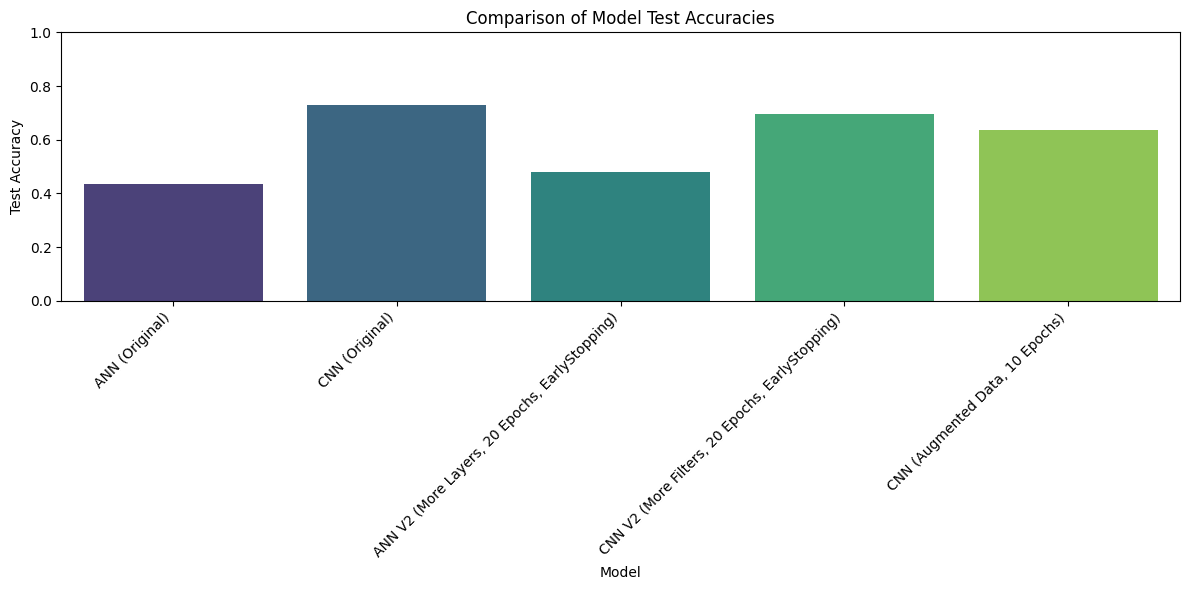

In [23]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Test Accuracy', data=comparison, palette='viridis')
plt.ylim(0, 1)
plt.title('Comparison of Model Test Accuracies')
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Performance Comparison: 10 vs 20 Epochs

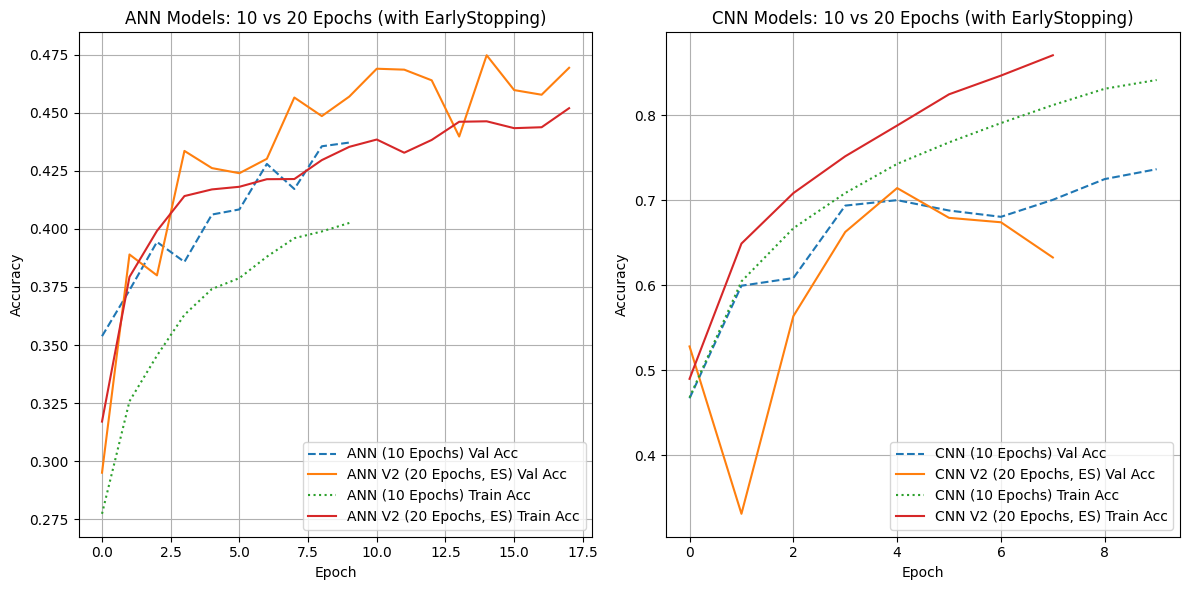

In [24]:
plt.figure(figsize=(12, 6))

# ANN Comparison
plt.subplot(1, 2, 1)
plt.plot(ann_history.history['val_accuracy'], label='ANN (10 Epochs) Val Acc', linestyle='--')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN V2 (20 Epochs, ES) Val Acc')
plt.plot(ann_history.history['accuracy'], label='ANN (10 Epochs) Train Acc', linestyle=':')
plt.plot(ann_history_v2.history['accuracy'], label='ANN V2 (20 Epochs, ES) Train Acc', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Models: 10 vs 20 Epochs (with EarlyStopping)")
plt.legend()
plt.grid(True)

# CNN Comparison
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['val_accuracy'], label='CNN (10 Epochs) Val Acc', linestyle='--')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN V2 (20 Epochs, ES) Val Acc')
plt.plot(cnn_history.history['accuracy'], label='CNN (10 Epochs) Train Acc', linestyle=':')
plt.plot(cnn_history_v2.history['accuracy'], label='CNN V2 (20 Epochs, ES) Train Acc', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Models: 10 vs 20 Epochs (with EarlyStopping)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**